# 🚖 Taxi Demand Prediction & Dispatch Planning

This notebook builds an end-to-end ML pipeline on the **NYC Taxi Trip Duration** dataset.  
Seven regression models are trained, compared, and their results saved for the project website.

**Target variable:** `trip_duration` (seconds, log-transformed)  
**Models:** Linear Regression · Ridge · Lasso · Decision Tree · Random Forest · Gradient Boosting

## 1. Imports & Setup

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, time

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
os.makedirs('results/plots', exist_ok=True)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print('All libraries loaded.')

All libraries loaded.


## 2. Load Dataset

In [14]:
choice = input('Train on (1) Sample [10,000 rows]  or  (2) Full dataset?  Enter 1 or 2: ').strip()

DATA_PATH = 'Data/NYC.csv'
if choice == '2':
    print('Loading full dataset - this may take a moment...')
    df = pd.read_csv(DATA_PATH)
else:
    print('Loading sample dataset (10,000 rows)...')
    df = pd.read_csv(DATA_PATH, nrows=10_000)

print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Loading full dataset - this may take a moment...
Loaded: 1,458,644 rows × 11 columns


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


## 3. Exploratory Data Analysis

In [15]:
print('Shape:', df.shape)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Shape: (1458644, 11)

Missing Values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

Basic Statistics:


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


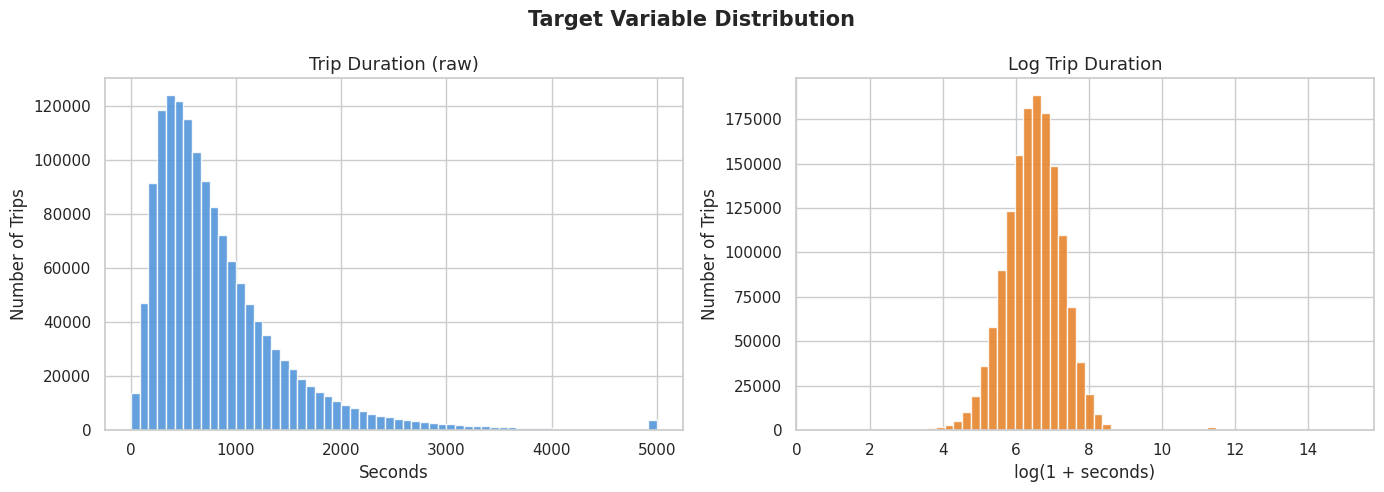

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['trip_duration'].clip(0, 5000), bins=60,
             color='#4A90D9', edgecolor='white', alpha=0.85)
axes[0].set_title('Trip Duration (raw)', fontsize=13)
axes[0].set_xlabel('Seconds'); axes[0].set_ylabel('Number of Trips')

axes[1].hist(np.log1p(df['trip_duration']), bins=60,
             color='#E67E22', edgecolor='white', alpha=0.85)
axes[1].set_title('Log Trip Duration', fontsize=13)
axes[1].set_xlabel('log(1 + seconds)'); axes[1].set_ylabel('Number of Trips')

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/eda_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Feature Engineering

New features derived from raw columns:
- **`hour`, `day_of_week`, `month`** - temporal patterns from pickup datetime
- **`distance_km`** - Haversine straight-line distance between pickup and dropoff
- **`store_and_fwd_flag`** - encoded as binary (1 = stored trip, 0 = live)

In [17]:
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two coordinate pairs."""
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['hour']        = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek
df['month']       = df['pickup_datetime'].dt.month

df['distance_km'] = haversine(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)
df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

print('Feature engineering complete, new feature added: distance_km')
df[['hour', 'day_of_week', 'month', 'distance_km', 'store_and_fwd_flag']].describe()

Feature engineering complete, new feature added: distance_km


,hour,day_of_week,month,distance_km,store_and_fwd_flag
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.360648e+01,3.050375e+00,3.516818e+00,3.440864e+00,5.515396e-03
std,6.399693e+00,1.954039e+00,1.681038e+00,4.296538e+00,7.406066e-02
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,9.000000e+00,1.000000e+00,2.000000e+00,1.231837e+00,0.000000e+00
50%,1.400000e+01,3.000000e+00,4.000000e+00,2.093717e+00,0.000000e+00
75%,1.900000e+01,5.000000e+00,5.000000e+00,3.875337e+00,0.000000e+00
max,2.300000e+01,6.000000e+00,6.000000e+00,1.240909e+03,1.000000e+00


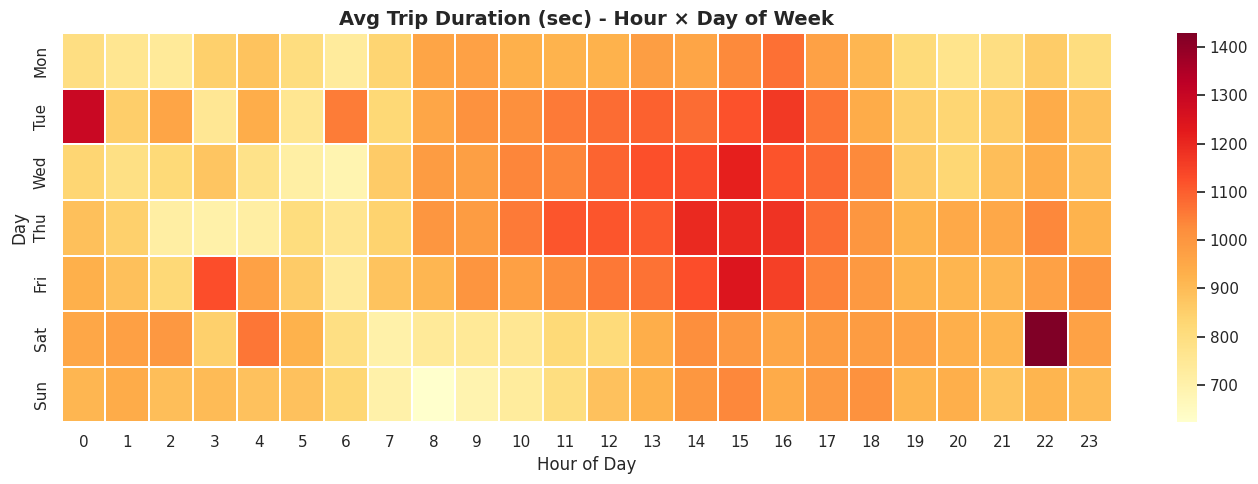

In [18]:
# Heatmap: average trip duration by hour and day of week
pivot = df.groupby(['day_of_week', 'hour'])['trip_duration'].mean().unstack()
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'][:len(pivot)]

plt.figure(figsize=(14, 5))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3)
plt.title('Avg Trip Duration (sec) - Hour × Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day'); plt.ylabel('Day')
plt.tight_layout()
plt.savefig('results/plots/eda_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Preprocessing

- **Outlier removal:** trips < 60 s or > 7200 s; distances < 0.1 km or > 50 km
- **Target transform:** `log1p(trip_duration)` - reduces right skew, improves linear model fit
- **Split:** 80 % train / 20 % test
- **Scaling:** `StandardScaler` applied only to the three linear models

In [19]:
df = df[(df['trip_duration'] >= 60) & (df['trip_duration'] <= 7200)]
df = df[(df['distance_km'] >= 0.1) & (df['distance_km'] <= 50)]

df['log_duration'] = np.log1p(df['trip_duration'])

FEATURES = [
    'vendor_id', 'passenger_count',
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude',
    'store_and_fwd_flag', 'hour', 'day_of_week', 'month', 'distance_km'
]

X = df[FEATURES]
y = df['log_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print(f'Rows after cleaning : {len(df):,}')
print(f'Training samples    : {len(X_train):,}')
print(f'Test samples        : {len(X_test):,}')
print(f'Features            : {FEATURES}')

Rows after cleaning : 1,440,195
Training samples    : 1,152,156
Test samples        : 288,039
Features            : ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'hour', 'day_of_week', 'month', 'distance_km']


## 6. Model Training & Evaluation

All seven models share the same train/test split.  
Linear models (LR, Ridge, Lasso) receive scaled features; tree-based models receive raw features.

In [20]:
MODELS = {
    'Linear Regression' : (LinearRegression(),                                                        True),
    'Ridge Regression'  : (Ridge(alpha=1.0),                                                         True),
    'Lasso Regression'  : (Lasso(alpha=0.001, max_iter=5000),                                        True),
    'Decision Tree'     : (DecisionTreeRegressor(max_depth=10, random_state=42),                     False),
    'Random Forest'     : (RandomForestRegressor(n_estimators=100, max_depth=12,
                                                 random_state=42, n_jobs=-1),                        False),
    'Gradient Boosting' : (GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                                     learning_rate=0.1, random_state=42),            False),
    'XGBoost'           : (XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                                       random_state=42, n_jobs=-1, verbosity=0),                     False)
}

metrics, preds, trained = {}, {}, {}

for name, (model, use_scaled) in MODELS.items():
    print(f'\n Training: {name} ...')
    Xtr = X_tr_sc if use_scaled else X_train.values
    Xte = X_te_sc if use_scaled else X_test.values
    t0 = time.time()
    model.fit(Xtr, y_train)
    elapsed = time.time() - t0
    y_pred = model.predict(Xte)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    metrics[name] = {'RMSE': round(rmse,4), 'R2': round(r2,4), 'MAE': round(mae,4), 'Time_s': round(elapsed,2)}
    preds[name]   = y_pred
    trained[name] = model
    print(f'    {name} -> RMSE: {rmse:.4f}  |  R2: {r2:.4f}  |  MAE: {mae:.4f}  |  Time_s: {elapsed:.1f}s')

print('\n All 7 models trained successfully!')


 Training: Linear Regression ...
    Linear Regression -> RMSE: 0.5277  |  R2: 0.4697  |  MAE: 0.4131  |  Time_s: 0.2s

 Training: Ridge Regression ...
    Ridge Regression -> RMSE: 0.5277  |  R2: 0.4697  |  MAE: 0.4131  |  Time_s: 0.1s

 Training: Lasso Regression ...
    Lasso Regression -> RMSE: 0.5277  |  R2: 0.4696  |  MAE: 0.4132  |  Time_s: 0.2s

 Training: Decision Tree ...
    Decision Tree -> RMSE: 0.3766  |  R2: 0.7299  |  MAE: 0.2856  |  Time_s: 4.7s

 Training: Random Forest ...
    Random Forest -> RMSE: 0.3579  |  R2: 0.7561  |  MAE: 0.2689  |  Time_s: 38.2s

 Training: Gradient Boosting ...
    Gradient Boosting -> RMSE: 0.3514  |  R2: 0.7648  |  MAE: 0.2636  |  Time_s: 251.9s

 Training: XGBoost ...
    XGBoost -> RMSE: 0.3515  |  R2: 0.7647  |  MAE: 0.2636  |  Time_s: 1.3s

 All 7 models trained successfully!


## 7. Results & Comparison

In [21]:
metrics_df = pd.DataFrame(metrics).T.reset_index()
metrics_df.columns = ['Model', 'RMSE', 'R2', 'MAE', 'Time_s']
metrics_df = metrics_df.sort_values('RMSE').reset_index(drop=True)

metrics_df.to_csv('results/metrics.csv', index=False)
print('Model Performance (sorted by RMSE ↑ lower is better):')
metrics_df

Model Performance (sorted by RMSE ↑ lower is better):


,Model,RMSE,R2,MAE,Time_s
0,Gradient Boosting,0.3514,0.7648,0.2636,251.86
1,XGBoost,0.3515,0.7647,0.2636,1.34
2,Random Forest,0.3579,0.7561,0.2689,38.17
3,Decision Tree,0.3766,0.7299,0.2856,4.73
4,Lasso Regression,0.5277,0.4696,0.4132,0.16
5,Ridge Regression,0.5277,0.4697,0.4131,0.11
6,Linear Regression,0.5277,0.4697,0.4131,0.24


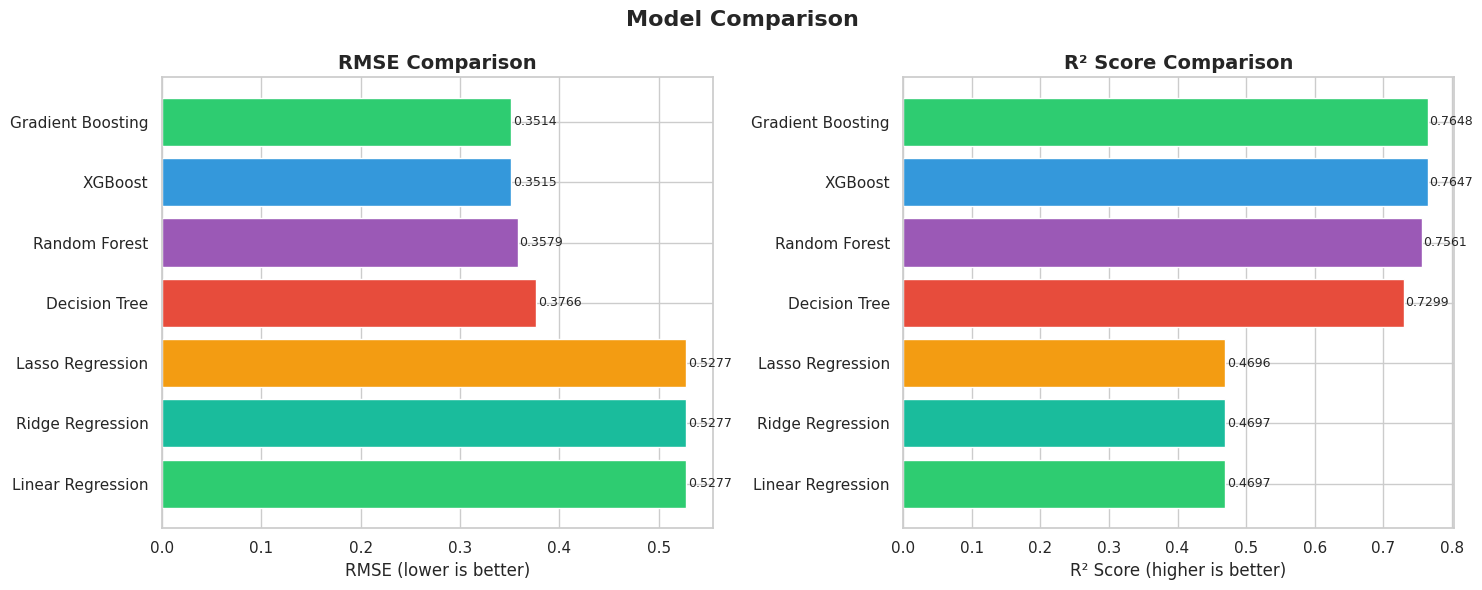

In [22]:
COLORS = ['#2ECC71','#3498DB','#9B59B6','#E74C3C','#F39C12','#1ABC9C']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# RMSE
bars = axes[0].barh(metrics_df['Model'], metrics_df['RMSE'],
                    color=COLORS[:len(metrics_df)], edgecolor='white')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
for b, v in zip(bars, metrics_df['RMSE']):
    axes[0].text(b.get_width()+0.002, b.get_y()+b.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)

# R²
bars2 = axes[1].barh(metrics_df['Model'], metrics_df['R2'],
                     color=COLORS[:len(metrics_df)], edgecolor='white')
axes[1].set_xlabel('R² Score (higher is better)')
axes[1].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
for b, v in zip(bars2, metrics_df['R2']):
    axes[1].text(b.get_width()+0.002, b.get_y()+b.get_height()/2,
                 f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

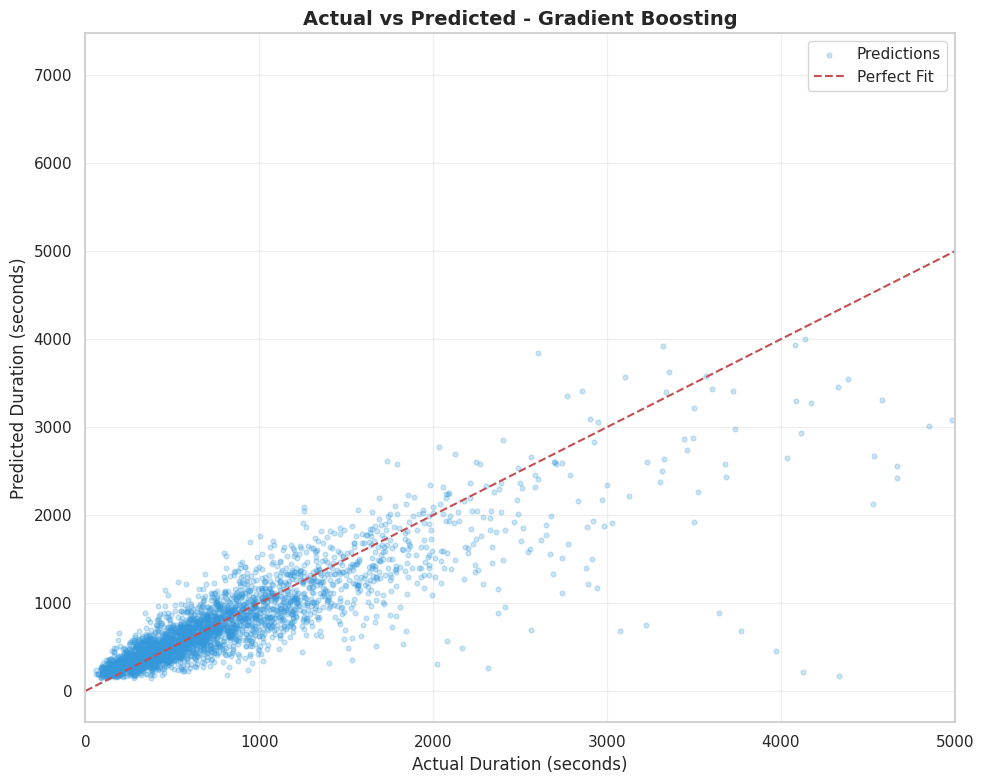

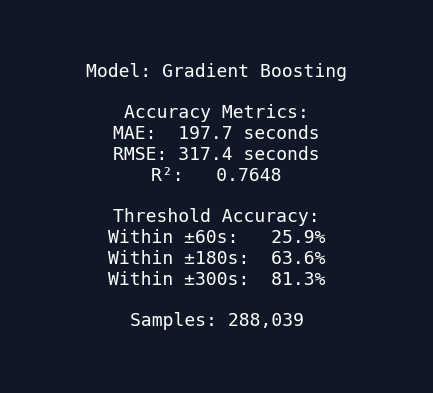

In [23]:
best = metrics_df.iloc[0]['Model']
y_pred_best = preds[best]
y_true = y_test.values

# Convert to seconds
actual_secs = np.expm1(y_true)
predicted_secs = np.expm1(y_pred_best)

# Calculate metrics in seconds
mae = mean_absolute_error(actual_secs, predicted_secs)
rmse = np.sqrt(mean_squared_error(actual_secs, predicted_secs))
r2_val = r2_score(y_true, y_pred_best)
within_60s = (np.abs(actual_secs - predicted_secs) <= 60).mean() * 100
within_180s = (np.abs(actual_secs - predicted_secs) <= 180).mean() * 100
within_300s = (np.abs(actual_secs - predicted_secs) <= 300).mean() * 100

# Figure 1: Scatter plot in seconds (larger, standalone)
fig1, ax1 = plt.subplots(figsize=(10, 8))
sample_idx = np.random.choice(len(actual_secs), 3000, replace=False)
ax1.scatter(actual_secs[sample_idx], predicted_secs[sample_idx],
            alpha=0.25, s=12, color='#3498DB', label='Predictions')
lims = [0, max(actual_secs.max(), predicted_secs.max())]
ax1.plot(lims, lims, 'r--', lw=1.5, label='Perfect Fit')
ax1.set_xlim(0, 5000)
ax1.set_xlabel('Actual Duration (seconds)', fontsize=12)
ax1.set_ylabel('Predicted Duration (seconds)', fontsize=12)
ax1.set_title(f'Actual vs Predicted - {best}', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/plots/actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()

# Figure 2: Accuracy metrics (standalone box, compact, transparent background)
fig2, ax2 = plt.subplots(figsize=(4.2, 3.8))
fig2.patch.set_facecolor('#101828')
ax2.set_facecolor('#101828')
ax2.axis('off')

metrics_text = (
    f"Model: {best}\n\n"
    f"Accuracy Metrics:\n"
    f"MAE:  {mae:.1f} seconds\n"
    f"RMSE: {rmse:.1f} seconds\n"
    f"R²:   {r2_val:.4f}\n\n"
    f"Threshold Accuracy:\n"
    f"Within ±60s:   {within_60s:.1f}%\n"
    f"Within ±180s:  {within_180s:.1f}%\n"
    f"Within ±300s:  {within_300s:.1f}%\n\n"
    f"Samples: {len(actual_secs):,}"
)

ax2.text(0.5, 0.5, metrics_text,
         fontsize=13, family='monospace', color='white',
         verticalalignment='center', horizontalalignment='center',
         transform=ax2.transAxes)

plt.tight_layout(pad=0.2)
plt.savefig('results/plots/accuracy_metrics.png', dpi=120,
            bbox_inches='tight', transparent=False)
plt.show()

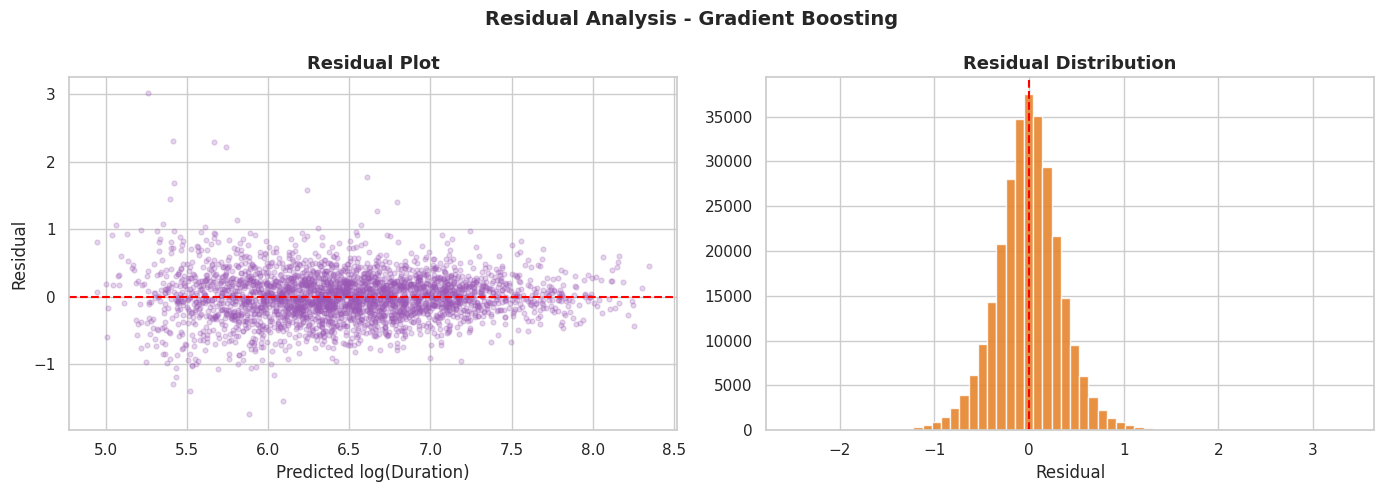

In [24]:
residuals = y_true - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_best[:3000], residuals[:3000],
                alpha=0.25, s=12, color='#9B59B6')
axes[0].axhline(0, color='red', linestyle='--', lw=1.5)
axes[0].set_xlabel('Predicted log(Duration)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residual Plot', fontsize=13, fontweight='bold')

axes[1].hist(residuals, bins=60, color='#E67E22', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_title('Residual Distribution', fontsize=13, fontweight='bold')

plt.suptitle(f'Residual Analysis - {best}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/plots/residuals.png', dpi=120, bbox_inches='tight')
plt.show()

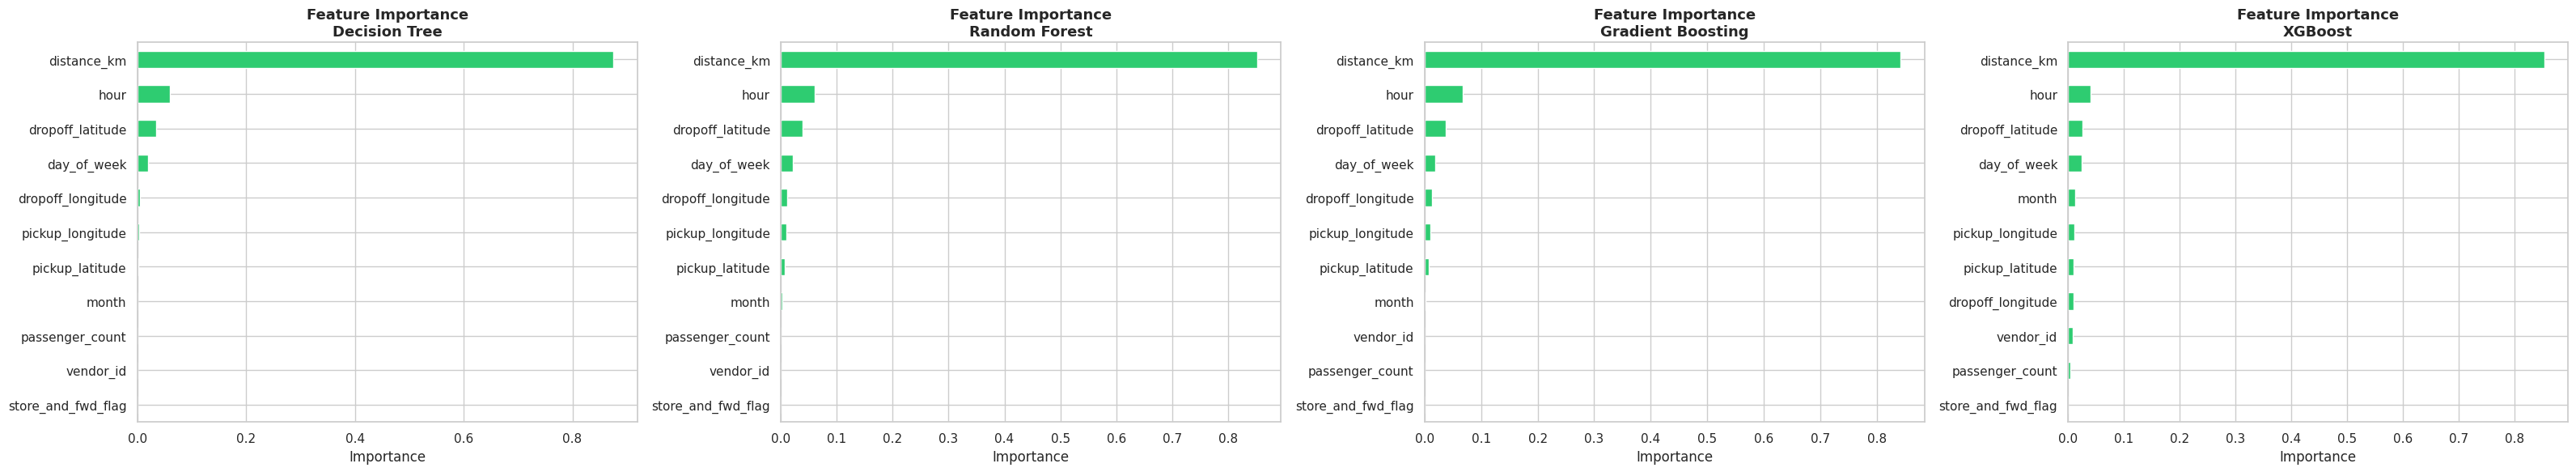

In [25]:
tree_models = {k: v for k, v in trained.items() if hasattr(v, 'feature_importances_')}
n = len(tree_models)
fig, axes = plt.subplots(1, n, figsize=(8*n, 6))
if n == 1: axes = [axes]

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=ax, color='#2ECC71', edgecolor='white')
    ax.set_title(f'Feature Importance\n{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('results/plots/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Export Results for Website

In [26]:
# Converts metrics to a JS file so the website can display them without a server
records = metrics_df.to_dict(orient='records')
js = 'const METRICS_DATA = ' + json.dumps(records, indent=2) + ';\n'
with open('results/results_data.js', 'w') as f:
    f.write(js)
print('results/results_data.js saved - website can now load the metrics table.')
print('All plots saved to results/plots/')

results/results_data.js saved - website can now load the metrics table.
All plots saved to results/plots/


## 9. Summary

| What | Detail |
|------|--------|
| Dataset | NYC Taxi Trip Duration (Kaggle) |
| Target | log1p(trip_duration) - seconds |
| Features | 11 (temporal + spatial + categorical) |
| Models compared | 7 regression algorithms |
| Best model | See metrics table |

**Key findings:**
- Tree-based models (Random Forest, Gradient Boosting) outperform linear models - trip duration has non-linear relationships with distance and time.
- `distance_km` and `hour` are typically the strongest predictors.
- Log-transforming the target helps linear models fit the heavily right-skewed distribution.
- Results saved to `results/` - open `website/index.html` to view the full dashboard.

## 8. Save Outputs

Save predictions and metrics so the Dispatch Planning notebook can load them directly.

In [27]:
# Save per-trip test predictions with coordinates for zone clustering in notebook 03.
pred_df = X_test.copy()
pred_df['actual_log']        = y_test.values
pred_df['predicted_log']     = y_pred_best
pred_df['actual_duration_s'] = np.expm1(y_test.values)
pred_df['predicted_duration_s'] = np.expm1(y_pred_best)
pred_df.to_csv('results/test_predictions.csv', index=False)
print(f'Saved {len(pred_df):,} test predictions -> results/test_predictions.csv')

Saved 288,039 test predictions -> results/test_predictions.csv
